# Teste de treinamento de modelo para predição de Resistência utilizando HGBR

In [5]:
%%capture
!pip install optuna

In [16]:
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
from google.colab import drive
from tqdm.notebook import tqdm
import seaborn as sns
import pandas as pd
import numpy as np
import os, optuna

### Montagem do drive

In [7]:
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
dirpath = '/content/drive/MyDrive/supervised-learning-studies/projeto/resistencia'
filename = 'df_resistencia_sem_feature_engineering.pkl'
file_path = os.path.join(dirpath, filename)
os.listdir(dirpath)
df = pd.read_pickle(file_path)
df['target'] = df['Resistencia_Compressao_MPa'].copy()
df.drop(inplace=True, columns=['Resistencia_Compressao_MPa'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 551 entries, 15 to 598
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Autores/ano                  551 non-null    object 
 1   Massa_Esp_Cimento_g_cm3      551 non-null    float64
 2   Finura_Cimento_Blaine_m2_kg  551 non-null    float64
 3   Massa_Esp_Filer_g_cm3        551 non-null    float64
 4   Massa_Esp_Areia_g_cm3        551 non-null    float64
 5   Massa_Esp_Brita_g_cm3        551 non-null    float64
 6   Cimento_kg_m3                551 non-null    float64
 7   Filer_Calcario_kg_m3         551 non-null    float64
 8   Agua_kg_m3                   551 non-null    float64
 9   Agregado_Miudo_Total_kg_m3   551 non-null    float64
 10  Agregado_Graudo_Total_kg_m3  551 non-null    float64
 11  Superplastificante_kg_m3     551 non-null    float64
 12  Relacao_Agua_Cimento         551 non-null    float64
 13  idade                   

In [13]:
n_groups = df['Autores/ano'].nunique()
print(f"Número de grupos únicos (Autores/ano): {n_groups}")
gkf = GroupKFold(n_splits=n_groups)

Número de grupos únicos (Autores/ano): 17


In [14]:
hyper_params = {
    "max_bins": 64,                # Reduzido por causa das 419 linhas
    "max_depth": 3,                # Mesma profundidade segura do XGBoost
    "min_samples_leaf": 12,        # Regularização forte na ponta
    "learning_rate": 0.05,
    "max_iter": 250,               # Equivalente ao n_estimators
    "l2_regularization": 10.0,     # Ridge penalty (L2)
    "random_state": 42,
    "early_stopping": True,      # OBRIGA o modelo a monitorar a validação
    "validation_fraction": 0.15, # Separa 15% do seu X_train internamente para gerar a linha de validação
    "n_iter_no_change": 250,
    "verbose": False
}

In [19]:
X = df.drop(columns=['target', 'Autores/ano'])
y = df['target']
groups = df['Autores/ano']

all_preds = []
all_true = []
all_groups = []
results = []
rmse_scores = []

splits = list(gkf.split(X, y, groups))

for fold, (train_idx, val_idx) in tqdm(enumerate(splits), desc="Executando treinamento...", unit="Fold", total=len(splits)):
    model = HistGradientBoostingRegressor(**hyper_params)

    X_train = X.iloc[train_idx].copy()
    X_val = X.iloc[val_idx].copy()

    y_train = y.iloc[train_idx].copy()
    y_val = y.iloc[val_idx].copy()

    model.fit(
        X_train,
        y_train
    )

    preds = model.predict(X_val)

    all_preds.extend(preds)
    all_true.extend(y_val)
    all_groups.extend(groups.iloc[val_idx])
    rmse = root_mean_squared_error(y_val, preds)
    rmse_scores.append(rmse)

Executando treinamento...:   0%|          | 0/17 [00:00<?, ?Fold/s]

In [21]:
debug_df = pd.DataFrame({
    'y_true': np.array(all_true).ravel(),
    'y_pred': np.array(all_preds).ravel(),
    'group': np.array(all_groups).ravel()
})

debug_df['residual'] = (
    debug_df['y_true'] - debug_df['y_pred']
)

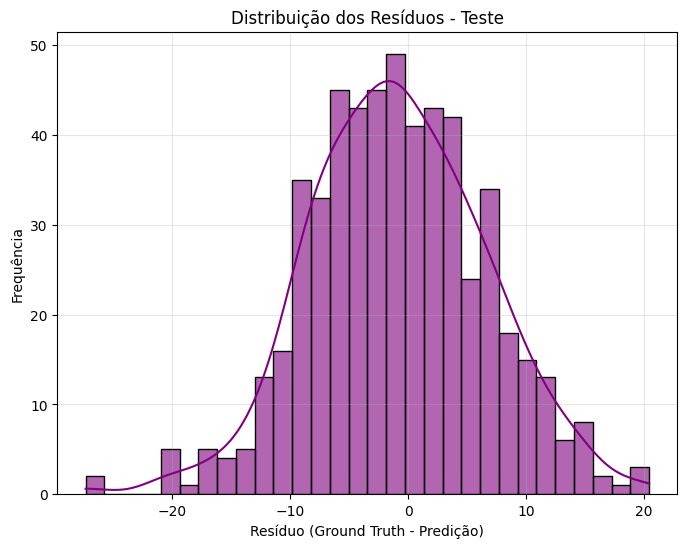

In [22]:
plt.figure(figsize=(8, 6))
sns.histplot(debug_df["residual"], bins=30, kde=True, color='purple', alpha=0.6)
plt.title("Distribuição dos Resíduos - Teste")
plt.xlabel("Resíduo (Ground Truth - Predição)")
plt.ylabel("Frequência")
plt.grid(True, alpha=0.3)
plt.show()

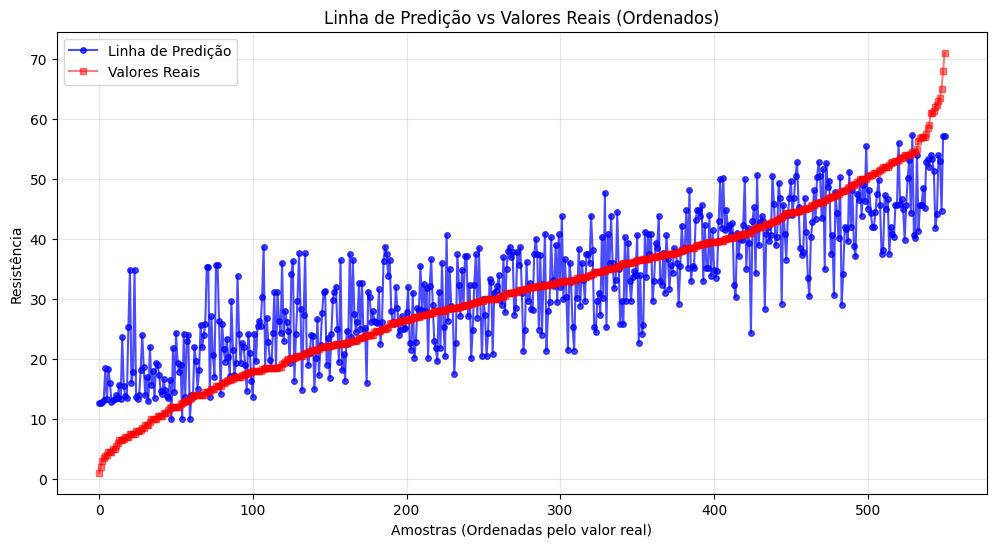

In [24]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
debug_df = debug_df.sort_values(by="y_true").reset_index(drop=True)
indices = range(len(debug_df))

plt.figure(figsize=(12, 6))

# 1. Linha das Predições (conectando os pontos preditos)
plt.plot(indices, debug_df["y_pred"], color='blue', label="Linha de Predição",
         alpha=0.7, linewidth=1.5, marker='o', markersize=4)

# 2. Pontos dos Valores Reais (Ground Truth)
plt.plot(indices, debug_df["y_true"], color='red', label="Valores Reais",
            alpha=0.5, linewidth=1.5, marker='s', markersize=4)

plt.title("Linha de Predição vs Valores Reais (Ordenados)")
plt.xlabel("Amostras (Ordenadas pelo valor real)")
plt.ylabel("Resistência")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [26]:
r2 = r2_score(debug_df["y_true"], debug_df["y_pred"])
rmse = root_mean_squared_error(debug_df["y_true"], debug_df["y_pred"])
mae = mean_absolute_error(debug_df["y_true"], debug_df["y_pred"])
mape = mean_absolute_percentage_error(debug_df["y_true"], debug_df["y_pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 7.4798
mean_absolute_error: 5.9464
mean_absolute_percentage_error: 0.3267
R² Score: 70.0208
